<a href="https://www.kaggle.com/code/umairali01/human-activity-recognition?scriptVersionId=324923855" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# 1. EDA
###  1. Missing values
###  2. Class distribution
###  3. Outlier detection
###  4. Data Encoding
###  5. Data Scaling

In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/umairali01/human-activity-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/umairali01/human-activity-dataset/test.csv")

In [3]:
train_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [4]:
train_df.isna().sum().sum()

np.int64(0)

In [5]:
train_df.isna().sum().sum()

np.int64(0)

In [6]:
train_df['Activity'].value_counts(normalize=True)*100

Activity
LAYING                19.137650
STANDING              18.688792
SITTING               17.491839
WALKING               16.675734
WALKING_UPSTAIRS      14.594668
WALKING_DOWNSTAIRS    13.411317
Name: proportion, dtype: float64

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'tBodyAcc-mean()-X'),
  Text(1, 0, 'tBodyAcc-mean()-Y'),
  Text(2, 0, 'tBodyAcc-mean()-Z'),
  Text(3, 0, 'tBodyAcc-std()-X'),
  Text(4, 0, 'tBodyAcc-std()-Y'),
  Text(5, 0, 'tBodyAcc-std()-Z'),
  Text(6, 0, 'tBodyAcc-mad()-X'),
  Text(7, 0, 'tBodyAcc-mad()-Y')])

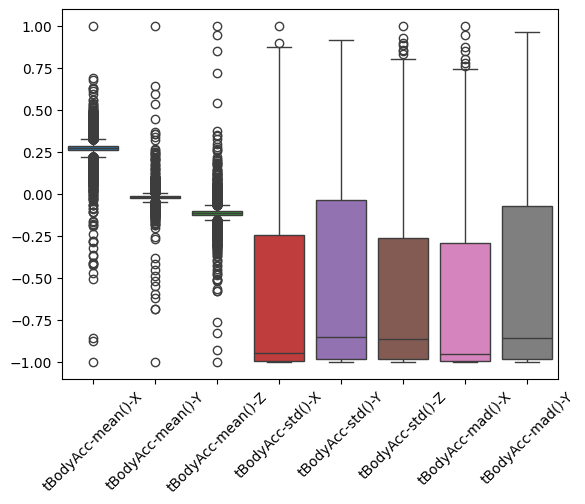

In [8]:
sns.boxplot(data=train_df[train_df.columns[:8]], orient='v')
plt.xticks(rotation=45)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(train_df['Activity'])
y_test_encoded = le.transform(test_df['Activity'])

In [10]:
y_train_encoded

array([2, 2, 2, ..., 5, 5, 5], shape=(7352,))

In [11]:
train_df['Activity']

0               STANDING
1               STANDING
2               STANDING
3               STANDING
4               STANDING
              ...       
7347    WALKING_UPSTAIRS
7348    WALKING_UPSTAIRS
7349    WALKING_UPSTAIRS
7350    WALKING_UPSTAIRS
7351    WALKING_UPSTAIRS
Name: Activity, Length: 7352, dtype: object

In [12]:
train_df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


# 2. Data Preparation 

In [13]:
train_df.shape, test_df.shape

((7352, 563), (2947, 563))

In [14]:
train_df['Activity']

0               STANDING
1               STANDING
2               STANDING
3               STANDING
4               STANDING
              ...       
7347    WALKING_UPSTAIRS
7348    WALKING_UPSTAIRS
7349    WALKING_UPSTAIRS
7350    WALKING_UPSTAIRS
7351    WALKING_UPSTAIRS
Name: Activity, Length: 7352, dtype: object

In [15]:
train_df['subject']

0        1
1        1
2        1
3        1
4        1
        ..
7347    30
7348    30
7349    30
7350    30
7351    30
Name: subject, Length: 7352, dtype: int64

In [16]:
X_train = train_df.drop(columns=["Activity", "subject"])

X_test = test_df.drop(columns=["Activity", "subject"])

In [17]:
X_train.shape

(7352, 561)

In [18]:
import torch

In [19]:
X_train_tensor = torch.tensor(data=X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(data=X_test.values, dtype=torch.float32)

In [20]:
X_train_tensor.shape

torch.Size([7352, 561])

In [21]:
y_train_tensor = torch.tensor(data=y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(data=y_test_encoded, dtype=torch.long)

In [22]:
y_train_tensor.shape

torch.Size([7352])

In [23]:
from torch.utils.data import TensorDataset

X = torch.tensor([[1,2],
                  [3,4],
                  [5,6]], dtype=torch.float32)

y = torch.tensor([0, 1, 0], dtype=torch.long)

dataset = TensorDataset(X, y)

In [24]:
dataset[1]

(tensor([3., 4.]), tensor(1))

In [25]:
X_train_tensor_dataset = TensorDataset(X_train_tensor, y_train_tensor)
X_test_tensor_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [26]:
X_train_tensor_dataset[0]

(tensor([ 0.2886, -0.0203, -0.1329, -0.9953, -0.9831, -0.9135, -0.9951, -0.9832,
         -0.9235, -0.9347, -0.5674, -0.7444,  0.8529,  0.6858,  0.8143, -0.9655,
         -0.9999, -0.9999, -0.9946, -0.9942, -0.9876, -0.9432, -0.4077, -0.6793,
         -0.6021,  0.9293, -0.8530,  0.3599, -0.0585,  0.2569, -0.2248,  0.2641,
         -0.0952,  0.2789, -0.4651,  0.4919, -0.1909,  0.3763,  0.4351,  0.6608,
          0.9634, -0.1408,  0.1154, -0.9852, -0.9817, -0.8776, -0.9850, -0.9844,
         -0.8947,  0.8921, -0.1613,  0.1247,  0.9774, -0.1232,  0.0565, -0.3754,
          0.8995, -0.9709, -0.9755, -0.9843, -0.9888, -0.9177, -1.0000, -1.0000,
          0.1138, -0.5904,  0.5911, -0.5918,  0.5925, -0.7454,  0.7209, -0.7124,
          0.7113, -0.9951,  0.9957, -0.9957,  0.9917,  0.5702,  0.4390,  0.9869,
          0.0780,  0.0050, -0.0678, -0.9935, -0.9884, -0.9936, -0.9945, -0.9862,
         -0.9928, -0.9852, -0.9920, -0.9931,  0.9898,  0.9920,  0.9905, -0.9935,
         -0.9999, -0.9998, -

In [27]:
from torch.utils.data import DataLoader

In [28]:
X_train_dataloader = DataLoader(X_train_tensor_dataset, batch_size=32, shuffle=True, drop_last=True )

In [29]:
X_test_dataloader = DataLoader(X_test_tensor_dataset, batch_size=32, shuffle=False, drop_last=True )

In [30]:
X_train_dataloader

# 3. Model Architecture

In [31]:
import torch.nn as nn

In [32]:
model = nn.Sequential(
    nn.Linear(561, 50),
    nn.ReLU(),
    nn.Linear(50, 6)
)

In [33]:
model

Sequential(
  (0): Linear(in_features=561, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=6, bias=True)
)

In [34]:
model.train()

Sequential(
  (0): Linear(in_features=561, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=6, bias=True)
)

In [35]:
Loss = nn.CrossEntropyLoss()

In [36]:
import torch.optim as optim

optimiser = optim.Adam(model.parameters(), lr=0.001)

# 4. Model Training

In [37]:
epochs = 20

for epoch in range(epochs):

    running_loss = 0.0

    for X_batch, y_batch in X_train_dataloader:

        # 1️⃣ Reset gradients
        optimiser.zero_grad()

        # 2️⃣ Forward pass
        outputs = model(X_batch)

        # 3️⃣ Compute loss
        loss = Loss(outputs, y_batch)

        # 4️⃣ Backpropagation
        loss.backward()

        # 5️⃣ Update weights
        optimiser.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(X_train_dataloader)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

Epoch [1/20] - Loss: 0.6134
Epoch [2/20] - Loss: 0.2355
Epoch [3/20] - Loss: 0.1530
Epoch [4/20] - Loss: 0.1194
Epoch [5/20] - Loss: 0.0965
Epoch [6/20] - Loss: 0.0860
Epoch [7/20] - Loss: 0.0770
Epoch [8/20] - Loss: 0.0731
Epoch [9/20] - Loss: 0.0650
Epoch [10/20] - Loss: 0.0628
Epoch [11/20] - Loss: 0.0588
Epoch [12/20] - Loss: 0.0571
Epoch [13/20] - Loss: 0.0543
Epoch [14/20] - Loss: 0.0537
Epoch [15/20] - Loss: 0.0552
Epoch [16/20] - Loss: 0.0509
Epoch [17/20] - Loss: 0.0466
Epoch [18/20] - Loss: 0.0446
Epoch [19/20] - Loss: 0.0480
Epoch [20/20] - Loss: 0.0492


# 5. Model Evaluation

In [38]:
model.eval()

Sequential(
  (0): Linear(in_features=561, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=6, bias=True)
)

In [39]:
test_predict = []
test_actual = []

with torch.no_grad():
    for X_batch, y_batch in X_test_dataloader:
        output = model(X_batch)
        max_val, max_val_index = torch.max(output, 1)
        test_predict.extend(max_val_index.numpy())
        test_actual.extend(y_batch.numpy())
        

In [40]:
train_predict = []
train_actual = []

with torch.no_grad():
    for X_batch, y_batch in X_train_dataloader:
        output = model(X_batch)
        max_val, max_val_index = torch.max(output, 1)
        train_predict.extend(max_val_index.numpy())
        train_actual.extend(y_batch.numpy())

In [41]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(train_actual, train_predict)

In [42]:
train_accuracy

0.9813045851528385

In [43]:
test_accuracy = accuracy_score(test_actual, test_predict)

In [44]:
test_accuracy

0.9341032608695652